Best fit line equation: y = 0.0000000000x + 0.0000000000
Best fit line: V= 1.262431474349262e-16 + 2.61133821146014e-12


Text(0, 0.5, 'Vj+Vn (V)')

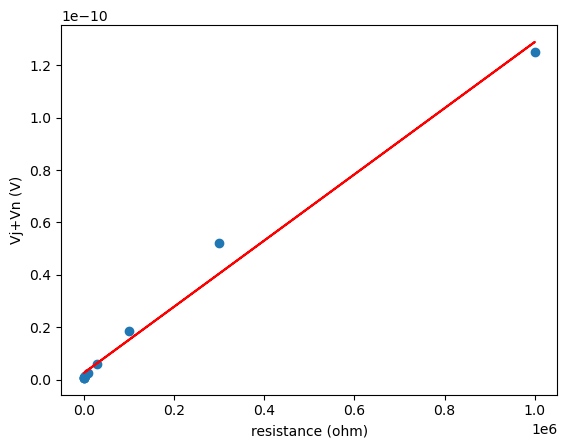

In [2]:
import numpy as np
import matplotlib.pyplot as plt

R= [1,
10,
100,
1000,
10000,
100000,
1000000,
300000,
30000,
3000]

Vj_Vn= [
    6.844e-13,
    6.844e-13,
    7.044e-13,
    8.633e-13,
    2.484e-12,
    1.852e-11,
    1.251e-10,
    5.200e-11,
    6.152e-12,
    1.230e-12
]


# plt.scatter(R, V)

fit=np.polyfit(R,Vj_Vn, 1)
bestfitline=np.polyval(fit, R)

slope=fit[0]
intercept=fit[1]

print(f"Best fit line equation: y = {slope:.10f}x + {intercept:.10f}")

# plt.errorbar(current, avg_tesla ,yerr=r_err, linestyle='none', capsize=5, ecolor='blue', label='Errorbar')

plt.plot(R, bestfitline,color='red') 
print(f"Best fit line: V= {slope:} + {intercept:}")

plt.scatter(R, Vj_Vn)
plt.xlabel('resistance (ohm)')
plt.ylabel('Vj+Vn (V)')
# plt.legend()


[-1.92693821146014e-12, -1.92693821146014e-12, -1.90693821146014e-12, -1.7480382114601401e-12, -1.2733821146014018e-13, 1.590866178853986e-11, 1.2248866178853988e-10, 4.938866178853986e-11, 3.5406617885398595e-12, -1.38133821146014e-12]
Slope = 1.2624314743492623e-16
Uncertainty in slope = 4.982057990311638e-18
Best fit line: V= 1.2624314743492623e-16 + 0.0


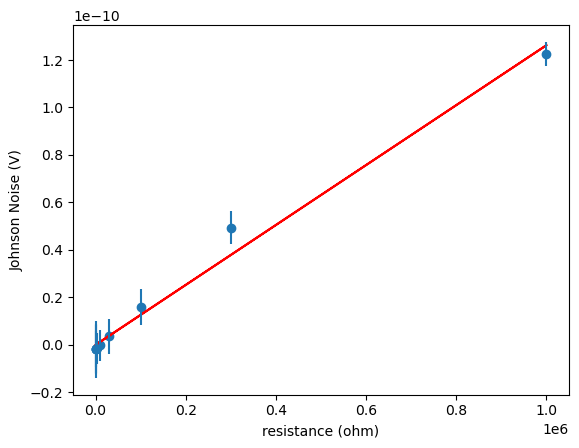

In [19]:
V_n= 2.61133821146014e-12
V_j = [x - V_n for x in Vj_Vn]


print(V_j)

(m, b), cov = np.polyfit(R, V_j, 1, cov=True)
bestfitline=np.polyval((m,b), R)

slope = m
intercept= b
slope_uncertainty = np.sqrt(cov[0, 0])

print("Slope =", slope)
print("Uncertainty in slope =", slope_uncertainty)
err = [
    0.007549834435,
    0.01201388086,
    0.01006644591,
    0.01058300524,
    0.006557438524,
    0.007505553499,
    0.005131601439,
    0.006806859286,
    0.007211102551,
    0.006557438524
]
err_bars=[x*1e-9 for x in err]
# print(f"Best fit line equation: y = {slope:.10f}x + {intercept:.10f}")


plt.plot(R, bestfitline,color='red') 
plt.errorbar(R, V_j , yerr=err_bars, linestyle= 'none',label='error bars')

print(f"Best fit line: V= {slope:} + {intercept:}")
# print(len(R), len(V_j), len(err_bars))

plt.scatter(R, V_j)
plt.xlabel('resistance (ohm)')
plt.ylabel('Johnson Noise (V)')
# plt.legend()
plt.savefig('Johnson Noise vs Resistance', dpi = 300)



Slope = 7.923756318847357e-17
Intercept = -1.0276840412745623e-13
R² = 0.25650785828552336
Weighted slope uncertainty = 5.579542290791628e-20


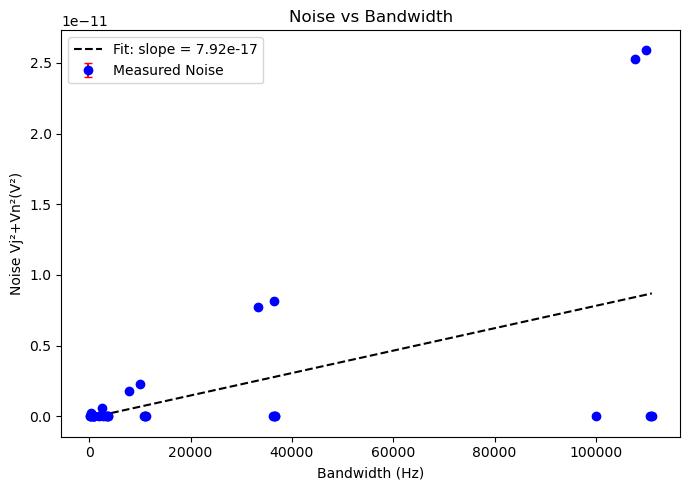

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# --- 1. Data ---
bandwidth = np.array([
    320, 990, 3654, 11096, 36643, 111050,
    300, 970, 3632, 11074, 36620, 99970,
    220, 900, 3554, 10996, 36543, 110961,
    30, 700, 3332, 10774, 36321, 110739,
    670, 0, 2576, 9997, 36543, 109961,
    2670, 2000, 300, 7839, 33324, 107740
], dtype=float)

noise = np.array([
    8.16e-20, 2.58e-19, 8.43e-19, 2.51e-18, 8.46e-18, 2.59e-17,
    7.85e-20, 2.50e-19, 8.37e-19, 2.53e-18, 8.46e-18, 2.59e-17,
    6.33e-20, 2.28e-19, 8.12e-19, 2.49e-18, 8.47e-18, 2.60e-17,
    2.52e-20, 1.79e-19, 7.63e-19, 2.43e-18, 8.37e-18, 2.59e-17,
    2.64e-15, 6.39e-14, 6.05e-13, 2.30e-12, 8.19e-12, 2.59e-11,
    6.02e-15, 6.88e-15, 2.45e-13, 1.78e-12, 7.74e-12, 2.53e-11
], dtype=float)

noise_sd = np.array([
    3.00e-15, 4.56e-15, 9.49e-15, 2.32e-14, 2.47e-14, 1.30e-13,
    3.34e-15, 5.77e-15, 1.20e-14, 1.11e-14, 5.14e-14, 1.09e-13,
    1.25e-15, 7.54e-15, 1.61e-14, 2.35e-14, 4.94e-14, 5.56e-14,
    8.49e-16, 2.64e-15, 1.12e-14, 3.13e-14, 4.33e-14, 1.11e-13,
    5.56e-17, 2.08e-15, 7.00e-15, 5.04e-14, 2.78e-14, 9.02e-14,
    1.61e-16, 7.00e-17, 2.82e-15, 2.63e-14, 5.78e-14, 7.00e-14
], dtype=float)

# --- 2. Clean Data ---
valid_mask = bandwidth > 0
x_data = bandwidth[valid_mask]
y_data = noise[valid_mask]
y_err = noise_sd[valid_mask]

# --- 3. Fit ---
slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)

# --- 4. Plot (Linear) ---
plt.figure(figsize=(7,5))

plt.errorbar(
    x_data, y_data, yerr=y_err,
    fmt='o', color='blue', ecolor='red',
    capsize=3, label='Measured Noise'
)

# Fit line
x_fit = np.linspace(min(x_data), max(x_data), 500)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, 'k--', label=f"Fit: slope = {slope:.2e}")

plt.xlabel("Bandwidth (Hz)")
plt.ylabel("Noise Vj²+Vn²(V²)")
plt.title("Noise vs Bandwidth")

plt.legend()
#plt.ylim(0,1)
#plt.xlim(0,40000)
plt.tight_layout()

plt.grid(False)
print("Slope =", slope)
print("Intercept =", intercept)
print("R² =", r_value**2)

w = 1 / (y_err**2)

S = np.sum(w)
Sx = np.sum(w * x_data)
Sxx = np.sum(w * x_data**2)

Delta = S * Sxx - Sx**2

slope_uncertainty = np.sqrt(S / Delta)

print("Weighted slope uncertainty =", slope_uncertainty)
plt.savefig('bandwidth dependence', dpi=300)